# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [9]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [10]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [11]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Let's read the dataset
df = pd.read_csv('/content/foodhub_order.csv')

In [13]:
# Displaying the first 5 rows of the dataset
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [14]:
# Checking the shape of the dataset
df.shape

(1898, 9)



#### Observations: The file has 1898 rows and 9 columns.



### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [15]:
# Checking the data types of the columns for the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are 5 numerical columns in the data and 4 object type columns. Rating is an object type, but it should be numerical type. From the first five rows of the data, it appears that the rating type includes "Not given" values when the ratings are not given. We need to replace "Not given" with "NaN" so that the ratings column should be classified as a numerical column.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [16]:
# Checking missing values of the dataset
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
There are no missing data in any of the columns. However, rating column includes the values of "Not given." We need to replace them with "NaN".

In [17]:
# replacing values with nan
df['rating'] = df['rating'].replace('Not given', np.nan)

# changing the data type to float
df['rating'] = df['rating'].astype(float)


In [18]:
# Let's check the data type of columns again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


We see that the data type of rating column has been fixed.
There are 6 numerical columns and 3 object type columns.
We observe that ratings columns have 1162 non-null values, indicating that there are missing values in the data.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [19]:
# Getting the statistical summary for the dataset
df.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:
The minimum time it takes for food to be prepared is 20 minutes. The average time is 27.37 minutes and maximum time is 35 minutes.

### **Question 5:** How many orders are not rated? [1 mark]

In [20]:
# Checking missing values
df['rating'].isnull().sum()

736

#### Observations:
There are 736 orders with no ratings.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

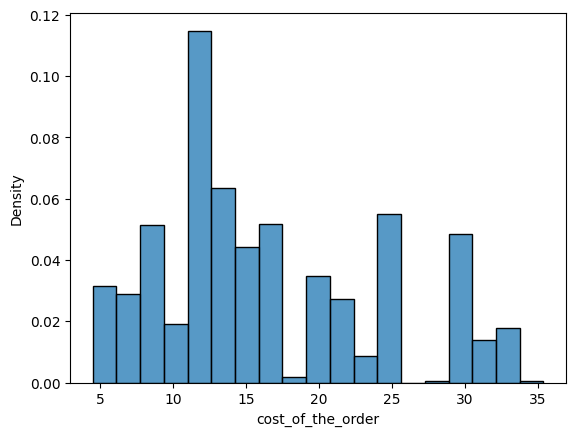

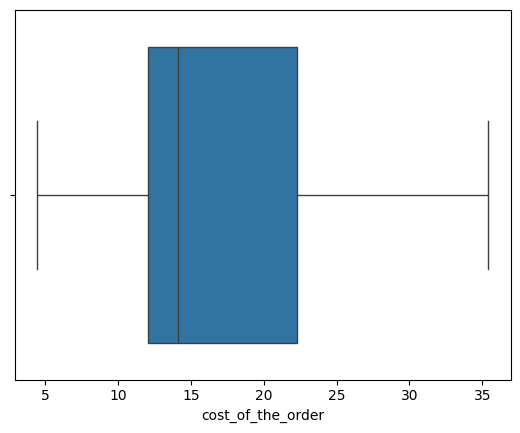

In [21]:
# Let's check the distribution for numerical columns
sns.histplot(data=df, x='cost_of_the_order', stat='density')
plt.show()
sns.boxplot(data=df, x='cost_of_the_order')
plt.show()

The distribution is skewed to the right, but there are no outliers.

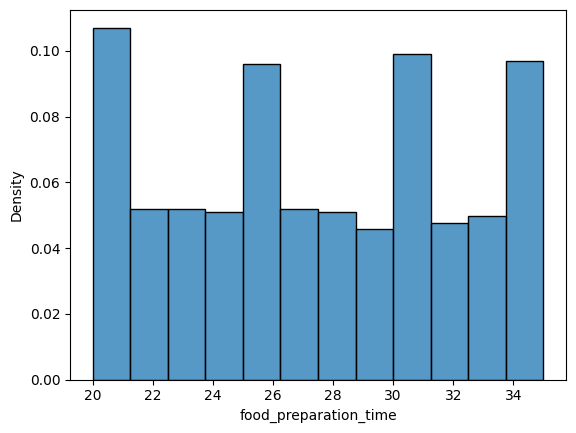

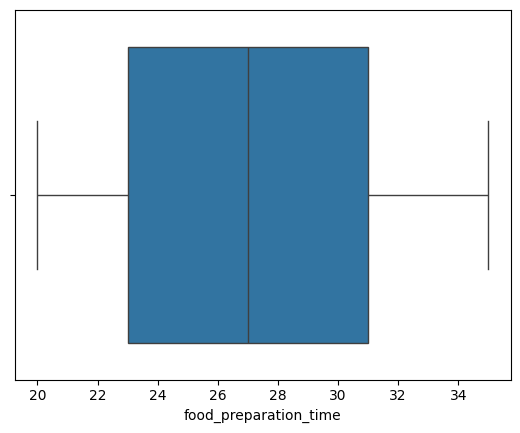

In [22]:
# Let's check the distribution for food_preparation_time.
sns.histplot(data=df, x='food_preparation_time', stat='density')
plt.show()
sns.boxplot(data=df, x='food_preparation_time')
plt.show()

The distribution for food_preparation_time is almost uniformly distributed with no outliers.

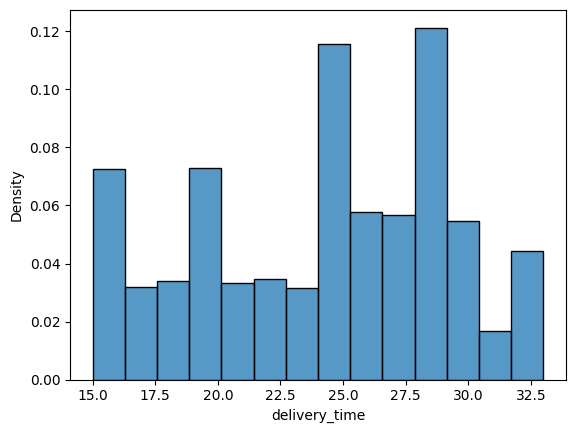

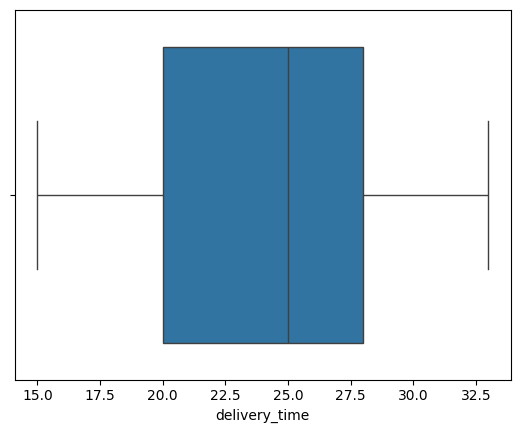

In [23]:
# Let's check the distribution for delivery_time.
sns.histplot(data=df, x='delivery_time', stat='density')
plt.show()
sns.boxplot(data=df, x='delivery_time')
plt.show()

The distribution for delivery_time is also mostly uniformly distributed with no outliers.

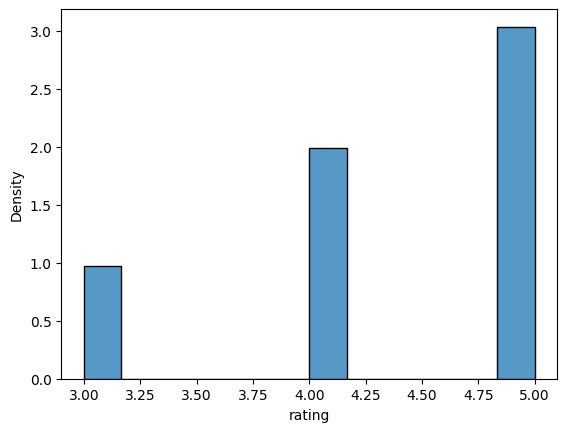

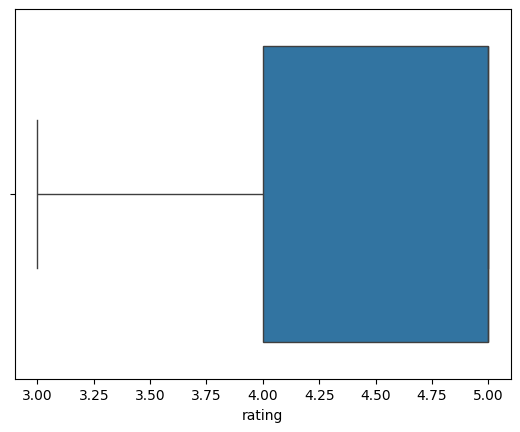

In [24]:
# Let's check the distribution for rating.
sns.histplot(data=df, x='rating', stat='density')
plt.show()
sns.boxplot(data=df, x='rating')
plt.show()

### The distribution for ratings is skewed to the left.

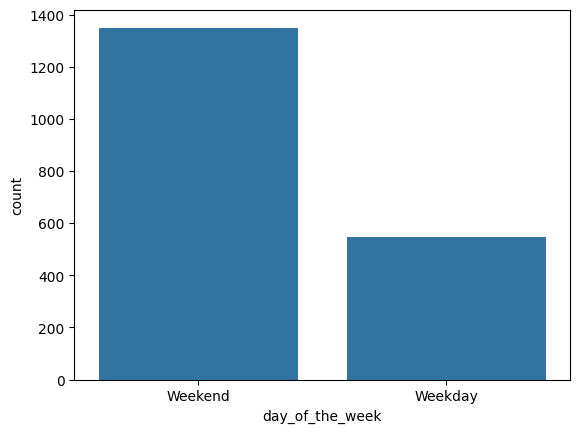

In [25]:
# Let's check the distribution for the day_of_the_week.
sns.countplot(data=df, x='day_of_the_week')
plt.show()

Weekend is more than twice weekday.

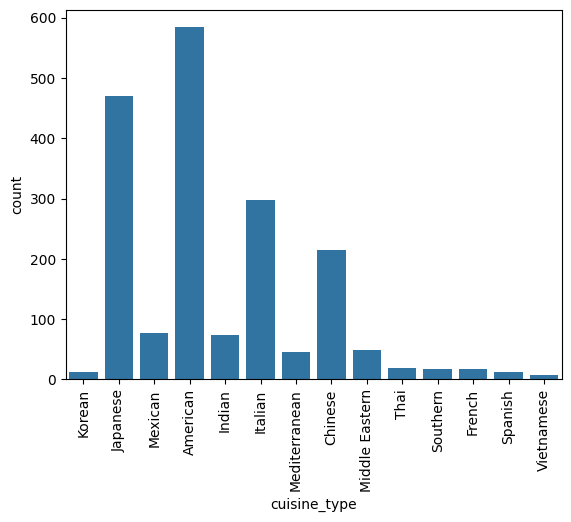

In [26]:
#Let's check the distribution for the cuisine_type.
sns.countplot(data=df, x='cuisine_type')
plt.xticks(rotation=90)
plt.show()

Most popular type of cuisine is American, followed by Japanese, Italian, and Chinese.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [65]:
# Getting the top 5 restaurants in terms of the number of orders received.
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: Here are the top 5 restaurants in terms of the number of orders received. 1. Shake Shake 219, 2. The Meatball Shop 132, 3. Blue Ribbon Sushi 119, 4. Blue Ribbon Fried Chicken 96, 5. Parm 68.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [30]:
# Checking the most popular cuisine on weekends.
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations: The most popular cuisine ordered on weekends is American.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [31]:
# Checking the percentage of orders that cost more than 20 dollars.
(df[df['cost_of_the_order'] > 20].shape[0] / df.shape[0]) * 100

29.24130663856691

#### Observations: 29.24% of the orders cost more than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [32]:
# Checking the mean order delivery_time.
df['delivery_time'].mean()

24.161749209694417

#### Observations: The mean order delivery time is 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [33]:
# Checking the customer_id of the top 3 most frequent customers and the number of orders they placed.
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: The customer id for the top 3 most frequent customers and the number of orders they placed are as follows.
The customer id 52832 placed 13 orders, followed by customer id of 47440 with 10 orders, and customer id of 83287 with 9 orders.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


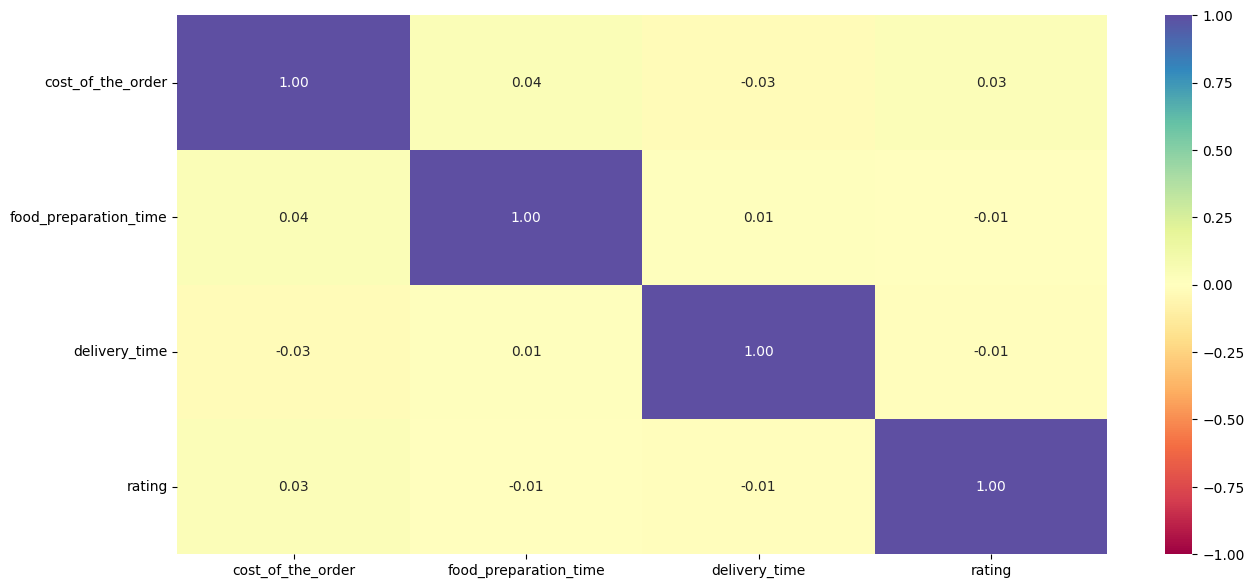

In [34]:
# Check for correlation among numerical variables
num_vars = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
corr_matrix = df[num_vars].corr()

# Plot the heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.show()

It appears that there are no correlations among numerical variables.

Let's check the correlation between numerical and categorical variables.

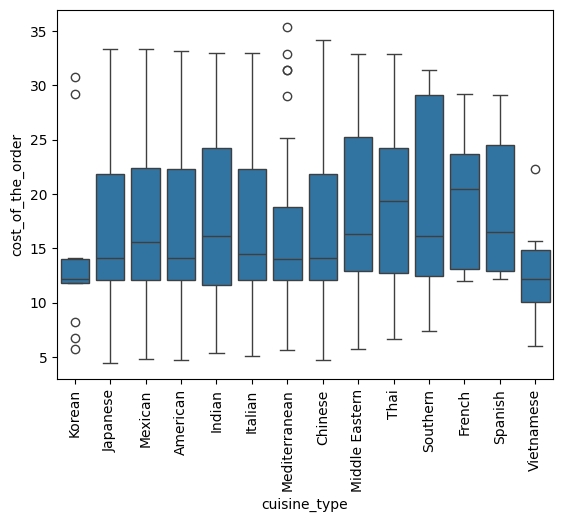

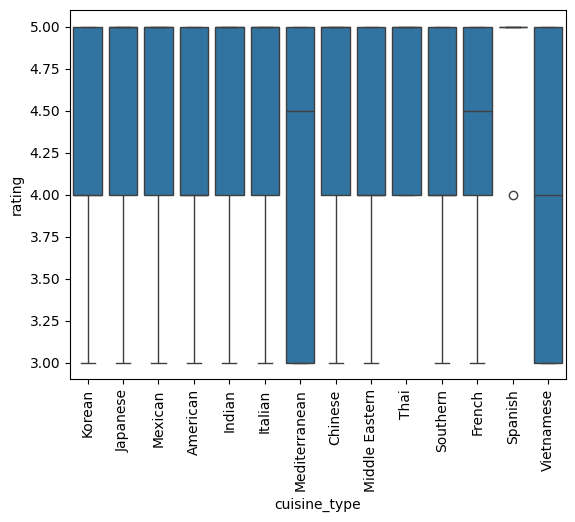

In [35]:
# Let's check the correlation between cuisine_type and cost and rating.
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)
plt.show()

sns.boxplot(data=df, x='cuisine_type', y='rating')
plt.xticks(rotation=90)
plt.show()

Top 3 cuisines with the highest cost of the order are French, Thai, and Indian, whereas the bottom 3 cuisines are Korean, Vietnamese, and Mediterranean.

Spanish cuisine had the highest rating while Mediterranean, French, and Vietnamese had the lowest rating.

In [63]:
# Find the number of ratings by cuisine type.
df.groupby('cuisine_type')['rating'].count().nlargest(3)

,rating
cuisine_type,
American,368
Japanese,273
Italian,172


Top 3 cuisine types in terms of rating are American, Japanese, and Italian.

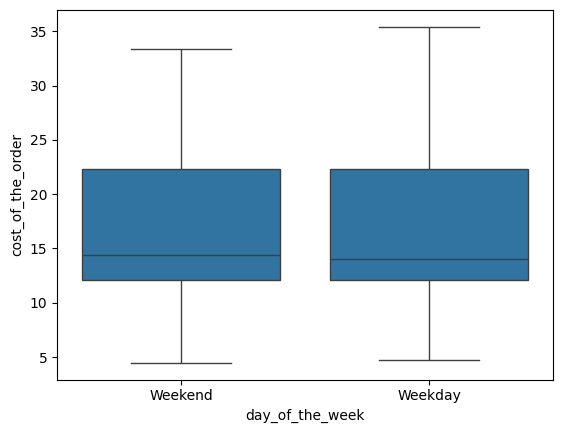

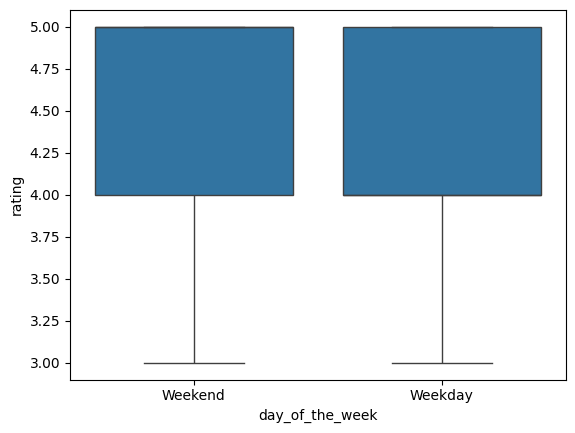

In [36]:
#Let's check the correlation between day_of_the_week and cost and day_of_the_week and rating
sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order')
plt.show()

sns.boxplot(data=df, x='day_of_the_week', y='rating')
plt.show()


There does not appear to be a correlation between day of the week and cost and day of the week and rating.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [43]:
# Checking the restaurants with rating count more than 50 and average rating greater than 4.
# Calculate average rating and count for each restaurant
restaurant_stats = df.groupby('restaurant_name')['rating'].agg(['mean', 'count'])# This code was obtained by explanation of errors.

# Filter restaurants based on conditions
filtered_restaurants = restaurant_stats[(restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)]# This code was obtained by explanation of errors.
filtered_restaurants

,mean,count
restaurant_name,,
Blue Ribbon Fried Chicken,4.328125,64
Blue Ribbon Sushi,4.219178,73
Shake Shack,4.278195,133
The Meatball Shop,4.511905,84


#### Observations: The restaurants that had more than 50 ratings and ratings greater 4 are Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [53]:
# Calculate net revenue generated by charging 25% fee on orders with
# cost greater than 20 dollars and 15% fee on orders with cost greater than 5 dollars.
df['net_revenue'] = np.where(df['cost_of_the_order'] > 20,
                             0.25 * df['cost_of_the_order'],
                             np.where(df['cost_of_the_order'] > 5,
                             0.15 * df['cost_of_the_order'],
                              0)) # Using where function to calculate net revenue for each condition
df['net_revenue'].sum()

6166.303

#### Observations: The net revenue generated by the company across all orders is $6,166.30.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [54]:
# Calculate the total time from order to delivery and find the percentage of orders
# that took more than 60 minutes.
df['total_time'] = df['delivery_time'] + df['food_preparation_time']
(df[df['total_time'] > 60].shape[0] / df.shape[0]) * 100

10.537407797681771

#### Observations: 10.5% of the orders took more than 60 minutes from placing the order to delivery.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

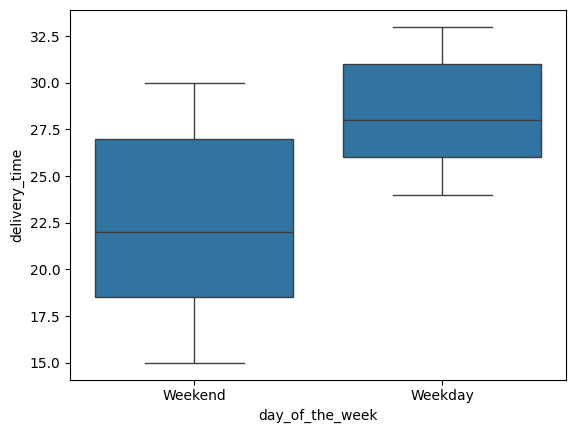

In [55]:
# Compare delivery_time between weekdays and weekends.
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.show()

In [56]:
#Calculate the mean delivery_time for weekdays and weekends.
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations: The mean delivery time for the weekdays is 28.3 minutes and the mean delivery time for weekdays is 22.5 minutes.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* Most popular type of cuisines in terms of the number of orders are American, followed by Japanese, Italian, and Chinese.
* Top 3 cuisine types in terms of number of ratings are American, Japanese, and Italian.


### Recommendations:

*  Based on the exploratory data analysis of Food Hub dataset, we recommend that the company focus on 3 most popular cuisine types in terms of number of orders placed and number of ratings received in order to drive the profitability and revenue of the business. The top 3 cuisine types are American, Japanese, and Italian.

---